In [1]:
import pandas as pd
import os
import shutil
import subprocess
from tqdm import tqdm
import json
from ast import literal_eval
import re
import requests
from Bio import pairwise2
import pickle
import sys
sys.path.append('../')
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

from common import *

/home/wuke/anaconda3/envs/AIGEM/lib/python3.7/site-packages/Bio/pairwise2.py:283: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  BiopythonDeprecationWarning,


# input and output

In [2]:
experiment_folder = '../../Data/Levodopa_strain_validation/'


In [3]:
strain_list = [
    "Control",
    "Clostridium baratii DA411",
    "Paraclostridium bifermentans DA1293",
    "Enterococcus faecalis DA462",
    "Enterococcus lactis DA470",
    "Enterococcus lactis DA296",
    "Enterococcus hirae DA802",
    "Enterococcus thailandicus DA450",
]

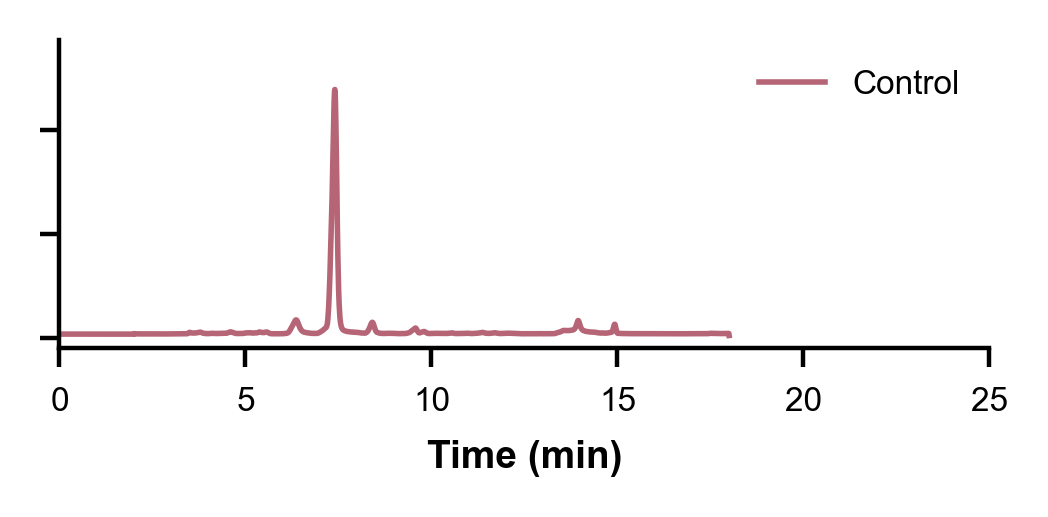

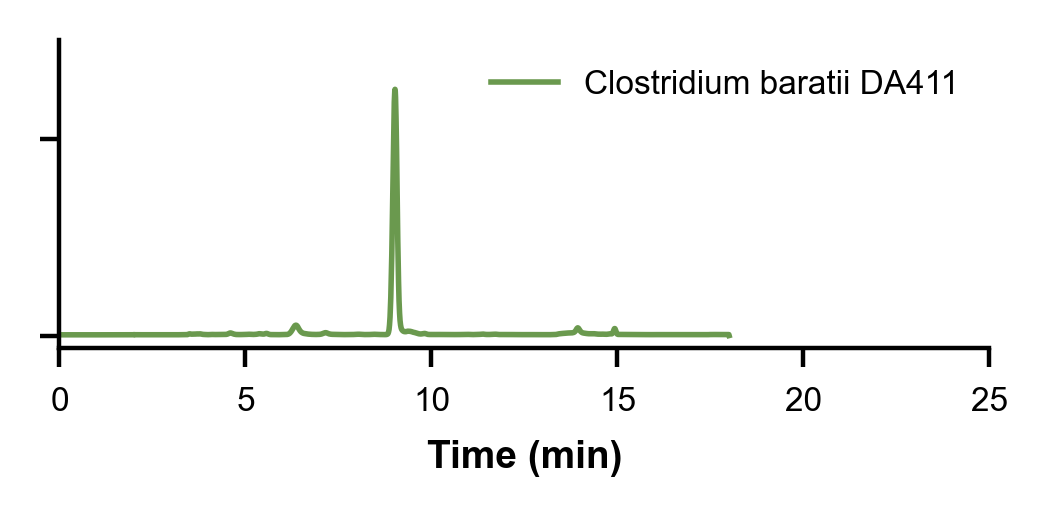

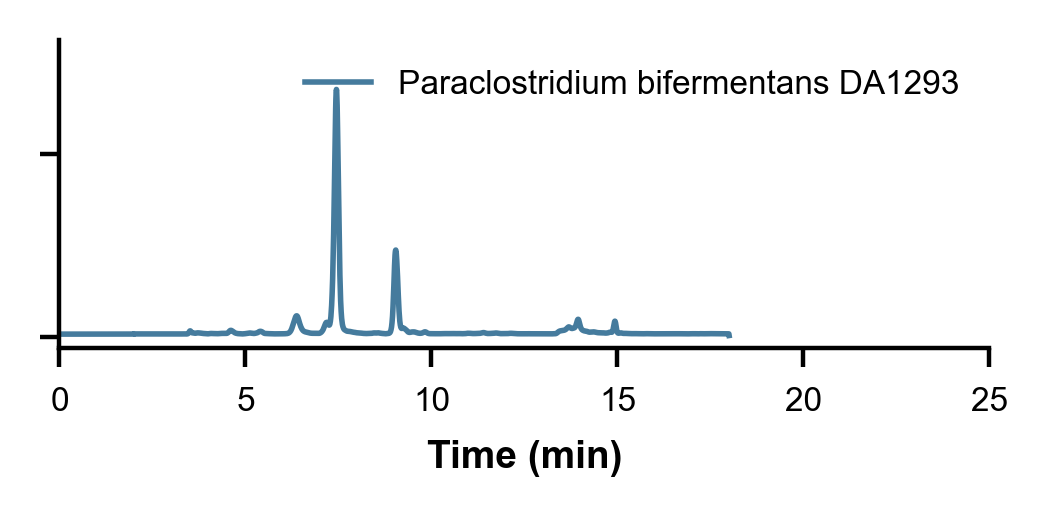

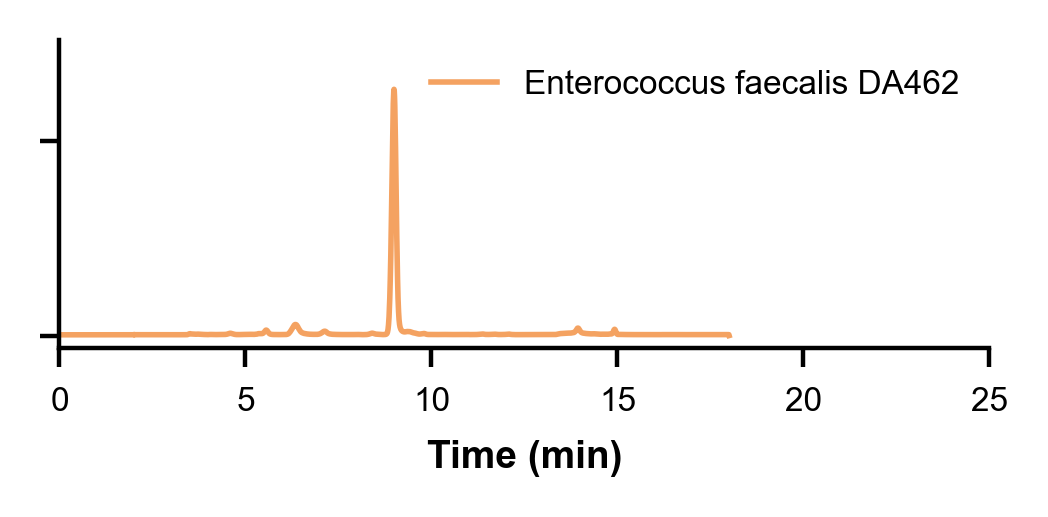

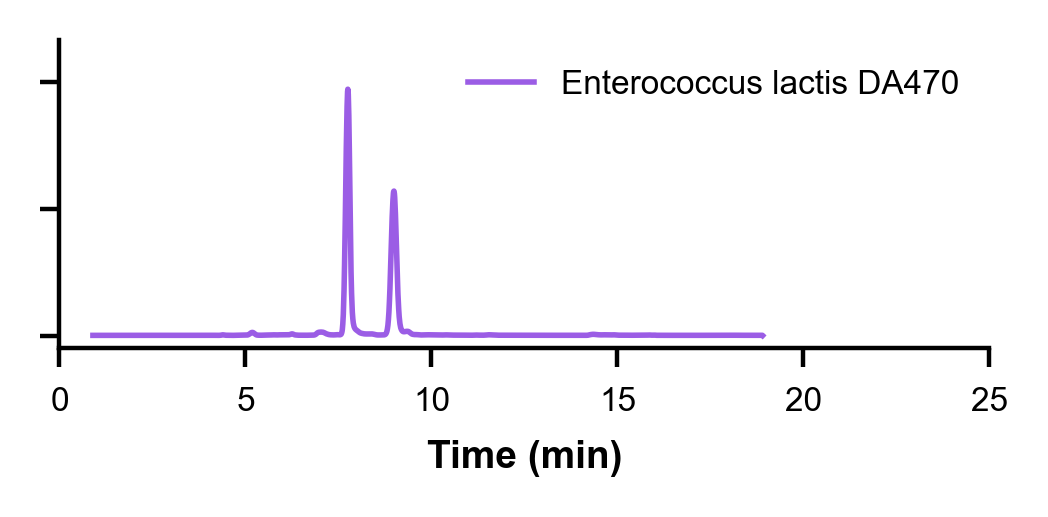

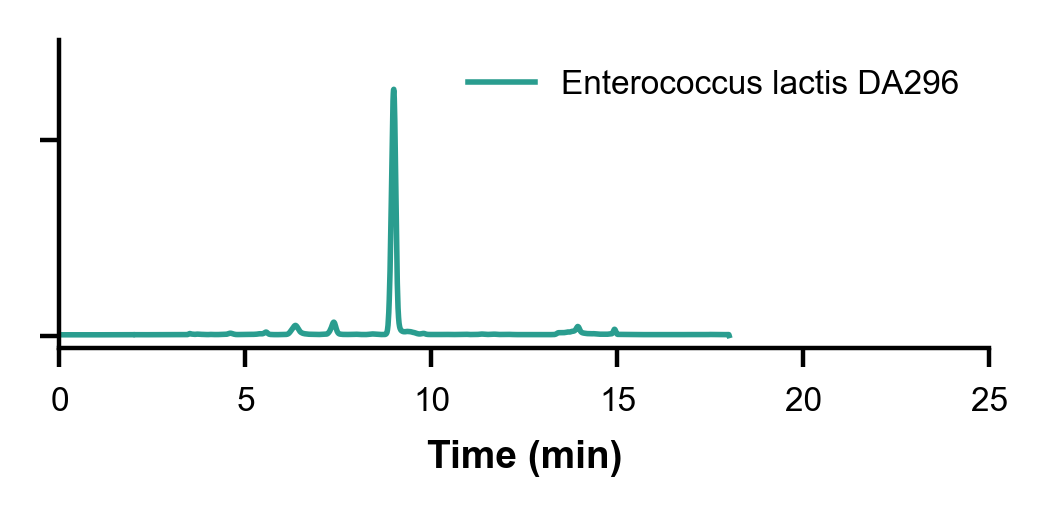

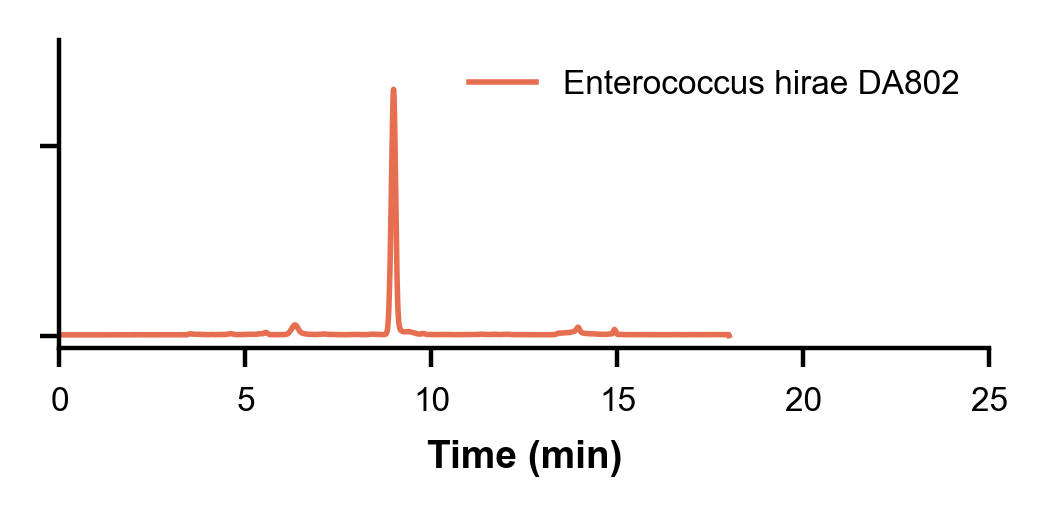

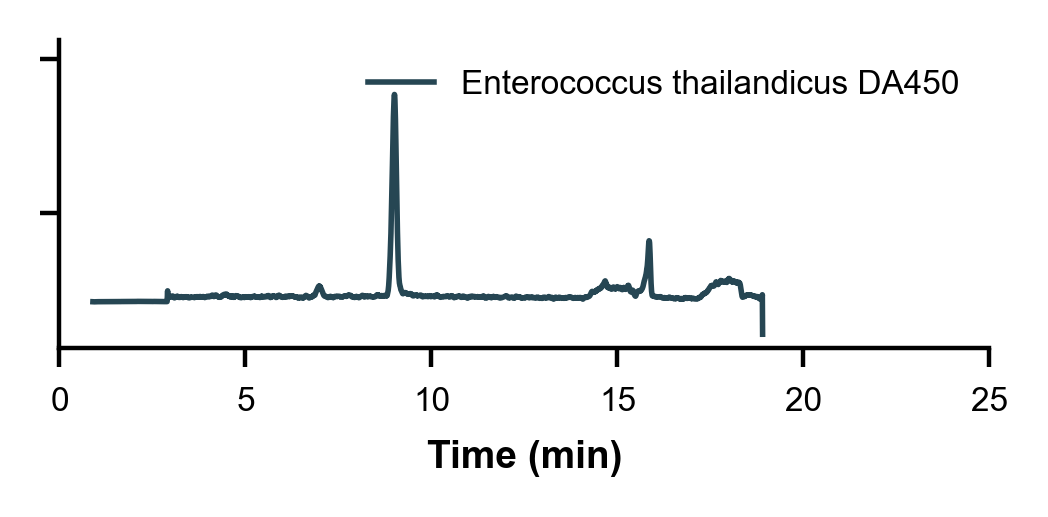

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 预定义颜色（8个菌）
colors = [
    '#B56576',
    '#6A994E',
    '#457B9D',
    '#F4A261',
    '#9B5DE5',
    '#2A9D8F',
    '#E76F51',
    '#264653'
]


for i in range(0, 8):

    strain = strain_list[i]
    file_name = strain.split(' ')[-1]

    experiment_file = pd.read_csv(experiment_folder + file_name + '.csv')

    # 数据
    x = experiment_file['X(min)']
    y = experiment_file['Y(Counts)']
    # 画布
    plt.figure(figsize=(3, 1), dpi=400)
    plt.rcParams.update({
        'font.size': 7,
        'font.family': 'Arial',
        'pdf.fonttype': 42
    })
    ax = plt.gca()
    ax.spines['top'].set_linewidth(0)
    ax.spines['right'].set_linewidth(0)
    # 折线
    plt.plot(x,y,color=colors[i],linewidth=1,label=strain)

    # 坐标
    plt.xlabel('Time (min)', fontsize=7, fontweight='bold')
    # plt.ylabel('Counts', fontsize=7, fontweight='bold')

    plt.xlim(0, 25)
    plt.ylim(min(y)-max(y)*0.05, max(y)*1.2)

    # tick
    plt.xticks(fontsize=6)
    plt.yticks(fontsize=6)

    plt.tick_params(axis='y',labelleft=False)

    # legend
    plt.legend(
        frameon=False,
        fontsize=6,
        loc='upper right'
    )
    fig_path= '../../Figure/Figure-S8-' + str(i) +'.pdf'
    plt.savefig(fig_path,dpi=400,bbox_inches='tight')
    plt.show()